# Solving ODEs using Implicit Methods

Recall that the general form of an $s$-stage Runge-Kutta method is

$$ \begin{align*}
  y_{n+1} &= y_n + h \sum_{i = 1}^s b_i k_i, \\
  k_i &= f(t_n + c_ih, y_n + h \sum_{j=1}^s a_{ij}k_j).
\end{align*} $$(irk-general-form)

Expanding out the summations in the stage values $k_i$

$$ \begin{align*}
  k_1 &= f(t_n + c_1h, y_n + h (a_{11}k_1 + a_{12}k_2 + \cdots + a_{1s}k_s)), \\
  k_2 &= f(t_n + c_2h, y_n + h (a_{21}k_1 + a_{22}k_2 + \cdots + a_{2s}k_s)), \\
  & \vdots \\
  k_s &= f(t_n + c_sh, y_n + h (a_{s1}k_1 + a_{s2}k_2 + \cdots + a_{ss}k_s)).
\end{align*} $$

The stage equations are implicit because the unknown stage values appear on both sides of the equations. So we need to recast the stage values so that we have a system of equations to solve. To make this easier we introduce a variable $Y_i$ for the second parameter of $f(t,y)$ in the stage value expressions, i.e., 

$$ Y_i = y_n + h \sum_{j=1}^s a_{ij} k_j, $$(irk-Yi)

and the expression for the stage values $k_i$ from {eq}`irk-general-form` becomes

$$ k_i = f(t_n + c_ih, Y_i). $$

Substituting this into equation {eq}`irk-Yi` gives

$$ Y_i = y_n + h \sum_{j=1}^s a_{ij} f(t_n + c_jh, Y_j), $$(irk-Yi-2)

and also into equation {eq}`irk-general-form` so the solution over a single step is

$$ y_{n+1} = y_n + h \sum_{i=1}^s b_i f(t_n + c_ih, Y_i). $$(irk-Yi-3)

For a general nonlinear function $f(t, y)$, equation {eq}`irk-Yi-2` is a system of $s$ nonlinear equations for the unknown stage values $Y_1, \ldots Y_s$​. In practice this system is usually solved using Newton's method.

To demonstrate the solution using an IRK method we are going to consider the solution of the IVP

$$ y' = ty, \qquad t \in [0, 1], \qquad y(0) = 1, $$

using the third-order RadauIA method which has the Butcher tableau

$$ \begin{array}{c|cc}
  0 & \frac{1}{4} & -\frac{1}{4} \\ 
  \frac{2}{3} & \frac{1}{4} & \frac{5}{12} \\
  \hline
  & \frac{1}{4} & \frac{3}{4}
\end{array} $$

and a step length of $h = 0.2$

Substituting the coefficients for the Radau IA method into equation {eq}`irk-Yi-2` we have

$$ \begin{align*}
  Y_1 &= y_n + h ( \tfrac{1}{4} f(t_n, Y_1) - \tfrac{1}{4} f(t_n + \tfrac{2}{3}h, Y_2)), \\
  Y_2 &= y_n + h ( \tfrac{1}{4} f(t_n, Y_1) + \tfrac{5}{12} f(t_n + \tfrac{2}{3}h, Y_2)).
\end{align*} $$

Since $f(t, y) = ty$ then this becomes

$$ \begin{align*}
  Y_1 &= y_n + h (\tfrac{1}{4} (t_nY_1) - \tfrac{1}{4} (t_n + \tfrac{2}{3}h)Y_2 ), \\
  Y_2 &= y_n + h (\tfrac{1}{4} (t_nY_1) + \tfrac{5}{12} (t_n + \tfrac{2}{3}h)Y_2 ).
\end{align*} $$

This is a system of linear equations, so we can re-write this in the form $A \mathbf{x} = \mathbf{b}$. Transposing the $Y_i$ terms to on the left-hand side gives

$$ \begin{align*}
  (1 - \tfrac{1}{4}ht_n)Y_1 + \tfrac{1}{4}h(t_n + \tfrac{2}{3}h)Y_2 &= y_n, \\
  -\tfrac{1}{4}ht_nY_1 + (1 - \tfrac{5}{12}h(t_n + \tfrac{2}{3}h))Y_2 &= y_n.
\end{align*} $$

Writing this as a matrix equation

$$ \begin{align*}
  \begin{pmatrix}
    1 - \tfrac{1}{4}ht_n & \frac{1}{4}h(t_n + \frac{2}{3}h) \\
    -\frac{1}{4}ht_n & 1 - \frac{5}{12}h(t_n + \frac{2}{3}h)
  \end{pmatrix}
  \begin{pmatrix} Y_1 \\ Y_2 \end{pmatrix}
  =
  \begin{pmatrix} y_n \\ y_n \end{pmatrix}.
\end{align*} $$

For the first step, $t_0 = 0$, $y_0 = 1$ and $h = 0.2$ so

$$ \begin{align*}
  \begin{pmatrix}
    1 & 0.0067 \\
    0 & 0.9889
  \end{pmatrix}
  \begin{pmatrix} Y_1 \\ Y_2 \end{pmatrix}
  =
  \begin{pmatrix} 1 \\ 1 \end{pmatrix}.
\end{align*} $$

Solving the linear system

$$ \begin{align*}
  \begin{pmatrix} Y_1 \\ Y_2 \end{pmatrix}
  = 
  \begin{pmatrix}
    1 & 0.0067 \\
    0 & 0.9889
  \end{pmatrix}^{-1}
  \begin{pmatrix} 1 \\ 1 \end{pmatrix}
  =
  \begin{pmatrix} 0.9933 \\ 1.0112 \end{pmatrix}
\end{align*} $$

So the stage values are $Y_1 = 0.9933$ and $Y_2 = 1.0112$. Note that although equation {eq}`irk-Yi-2` is generally nonlinear, for the test problem $f(t,y)=ty$ the stage values appear only linearly, resulting in a linear system that can be solved directly.

The solution of the ODE $y' = f(t, y)$ over a single time step using the third order RadauIA method is

$$y_{n+1} = y_n + h ( \tfrac{1}{4} f(t_n, Y_1) + \tfrac{3}{4} f(t_n + \tfrac{2}{3}h, Y_2)), $$

and since here $y' = ty$ then

$$ y_{n+1} = y_n + h (\tfrac{1}{4} t_n Y_1 + \tfrac{3}{4} (t_n + \tfrac{2}{3}h) Y_2). $$

So the solution over the first step is

$$ \begin{align*}
  y_1 &= 1 + 0.2 (\tfrac{1}{4}(0)(0.9933) + \tfrac{3}{4}(0 + \tfrac{2}{3}(0.2))(1.0112)) = 1.0202.
\end{align*} $$

The solution over the range $t \in [0, 1]$ using the third-order Radau IA method is tabulated below and plotted against the exact solution in {numref}`radauIA-example-plot`.

| $n$  |  $t_n$   |   $y_n$    |   $Y_1$   |   $Y_2$   |
|:--:|:----:|:------:|:------:|:------:|
| 0  | 0.00 | 1.0000 |   -    |   -    |
| 1  | 0.20 | 1.0202 | 0.9933 | 1.0112 |
| 2  | 0.40 | 1.0833 | 1.0127 | 1.0598 |
| 3  | 0.60 | 1.1973 | 1.0740 | 1.1562 |
| 4  | 0.80 | 1.3773 | 1.1847 | 1.3131 |
| 5  | 1.00 | 1.6490 | 1.3592 | 1.5524 |


```{glue:figure} radauIA_example_plot
:name: radauIA-example-plot
:figwidth: 600

The solution to the IVP $y'=ty$, $t \in [0,1]$, $y(0)=1$ using the third-order Radau IA method with $h=0.2$.
```

| n  |  t   |   y    |   Y1   |   Y2   |
|:--:|:----:|:------:|:------:|:------:|
| 0  | 0.00 | 1.0000 |   -    |   -    |
| 1  | 0.20 | 1.0202 | 0.9933 | 1.0112 |
| 2  | 0.40 | 1.0833 | 1.0127 | 1.0598 |
| 3  | 0.60 | 1.1973 | 1.0740 | 1.1562 |
| 4  | 0.80 | 1.3773 | 1.1847 | 1.3131 |
| 5  | 1.00 | 1.6490 | 1.3592 | 1.5524 |


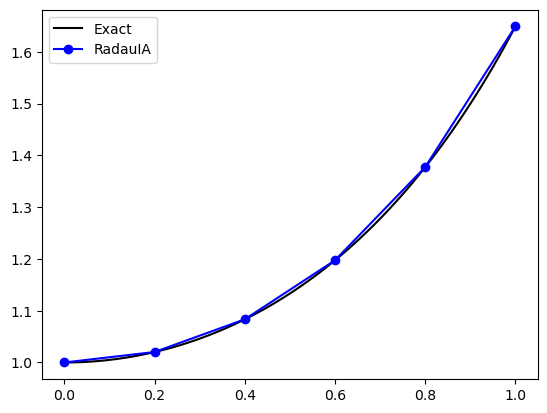

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define ODE function
def f(t, y):
  return t * y

# Define exact solution function
def exact(t):
    return np.exp(t ** 2 / 2)


# Define IVP paramters
h = 0.2
y0 = 1
tspan = [0, 1]

# Define solution arrays and assign initial values
nsteps = int((tspan[1] - tspan[0]) / h)
t = np.zeros(nsteps + 1)
y = np.zeros(nsteps + 1)
y[0] = y0
t[0] = tspan[0]

# Print table headers
print("| n  |  t   |   y    |   Y1   |   Y2   |")
print("|:--:|:----:|:------:|:------:|:------:|")
print(f"| {0}  | {t[0]:0.2f} | {y[0]:0.4f} |   -    |   -    |")

# Loop through steps
for n in range(nsteps):
    
    # Solve linear system for the stage values
    A = np.array([[ 1 - 1/4 * h * t[n], 1/4 * h * (t[n] + 2/3 * h)], 
                  [ -1/4 * h * t[n], 1 - 5/12 * h * (t[n] + 2/3 * h) ]])
    b = np.array([ y[n], y[n] ])
    Y = np.linalg.inv(A) @ b

    # Compute solution at the next step
    y[n+1] = y[n] + h * (0.25 * f(t[n], Y[0]) + 0.75 * f(t[n] + 2/3 * h, Y[1]))
    t[n+1] = t[n] + h

    # Print row
    print(f"| {n+1}  | {t[n+1]:0.2f} | {y[n+1]:0.4f} | {Y[0]:0.4f} | {Y[1]:0.4f} |")

# Compute exact solution
t_exact = np.linspace(tspan[0], tspan[1], 100)
y_exact = exact(t_exact)

# Plot solution
fig, ax = plt.subplots()
plt.plot(t_exact, y_exact, 'k', label="Exact")
plt.plot(t, y, 'b-o', label="RadauIA")
plt.legend()

from myst_nb import glue
glue("radauIA_example_plot", fig, display=False)